<a href="https://colab.research.google.com/github/kmunyaradzi/Pre-Trained-Model-Analysis/blob/main/train_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 2: Verifying PyTorch is installed (Colab comes with it)
import torch
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# dataset path
data_dir = '/content/drive/My Drive/pneumonia_detection/data/chest_xray'

print(f"\nChecking dataset at: {data_dir}")
if os.path.exists(data_dir):
    print("Dataset found!")
    print(f"Contents: {os.listdir(data_dir)}")
else:
    print("ERROR: Dataset not found. Please check the path.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Checking dataset at: /content/drive/My Drive/pneumonia_detection/data/chest_xray
Dataset found!
Contents: ['data_loader.py', '__MACOSX', 'train', 'val', 'test', 'chest_xray']


In [ ]:
# Cell 3: Creating 70/15/15 split from original dataset
import os
import shutil
import random
from sklearn.model_selection import train_test_split

print("=" * 60)
print("CREATING 70/15/15 DATASET SPLIT")
print("=" * 60)

# dataset path
original_path = '/content/drive/My Drive/pneumonia_detection/data/chest_xray'

# New path for organized splits
new_base_path = '/content/pneumonia_splits'

# Cleaning up previous split if it exists
if os.path.exists(new_base_path):
    shutil.rmtree(new_base_path)

# Creating new directory structure
for split in ['train', 'val', 'test']:
    for category in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(os.path.join(new_base_path, split, category), exist_ok=True)

# Getting all images paths from train folder
normal_images = []
pneumonia_images = []

normal_path = os.path.join(original_path, 'train', 'NORMAL')
pneumonia_path = os.path.join(original_path, 'train', 'PNEUMONIA')

if os.path.exists(normal_path):
    normal_images = [os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(('.jpeg', '.jpg', '.png'))]
if os.path.exists(pneumonia_path):
    pneumonia_images = [os.path.join(pneumonia_path, f) for f in os.listdir(pneumonia_path) if f.endswith(('.jpeg', '.jpg', '.png'))]

print(f"Found {len(normal_images)} NORMAL images")
print(f"Found {len(pneumonia_images)} PNEUMONIA images")

# Splitting NORMAL images: 70% train, 15% val, 15% test
normal_train, normal_temp = train_test_split(normal_images, test_size=0.3, random_state=42)
normal_val, normal_test = train_test_split(normal_temp, test_size=0.5, random_state=42)

# Spliting PNEUMONIA images: 70% train, 15% val, 15% test
pneumonia_train, pneumonia_temp = train_test_split(pneumonia_images, test_size=0.3, random_state=42)
pneumonia_val, pneumonia_test = train_test_split(pneumonia_temp, test_size=0.5, random_state=42)

# Copying files to new directories
def copy_files(file_list, destination_folder):
    for file_path in file_list:
        filename = os.path.basename(file_path)
        dest_path = os.path.join(destination_folder, filename)
        shutil.copy2(file_path, dest_path)

# Copying NORMAL files
copy_files(normal_train, os.path.join(new_base_path, 'train', 'NORMAL'))
copy_files(normal_val, os.path.join(new_base_path, 'val', 'NORMAL'))
copy_files(normal_test, os.path.join(new_base_path, 'test', 'NORMAL'))

# Copying PNEUMONIA files
copy_files(pneumonia_train, os.path.join(new_base_path, 'train', 'PNEUMONIA'))
copy_files(pneumonia_val, os.path.join(new_base_path, 'val', 'PNEUMONIA'))
copy_files(pneumonia_test, os.path.join(new_base_path, 'test', 'PNEUMONIA'))

print("\n" + "=" * 60)
print("SPLIT COMPLETE")
print("=" * 60)
print(f"Training set:   {len(normal_train) + len(pneumonia_train)} images")
print(f"  NORMAL: {len(normal_train)}, PNEUMONIA: {len(pneumonia_train)}")
print(f"Validation set: {len(normal_val) + len(pneumonia_val)} images")
print(f"  NORMAL: {len(normal_val)}, PNEUMONIA: {len(pneumonia_val)}")
print(f"Test set:       {len(normal_test) + len(pneumonia_test)} images")
print(f"  NORMAL: {len(normal_test)}, PNEUMONIA: {len(pneumonia_test)}")

# Updating dataset path to new split
DATASET_PATH = new_base_path
print(f"\nNew dataset path: {DATASET_PATH}")

CREATING 70/15/15 DATASET SPLIT
Found 1342 NORMAL images
Found 3877 PNEUMONIA images

SPLIT COMPLETE
Training set:   3652 images
  NORMAL: 939, PNEUMONIA: 2713
Validation set: 783 images
  NORMAL: 201, PNEUMONIA: 582
Test set:       784 images
  NORMAL: 202, PNEUMONIA: 582

New dataset path: /content/pneumonia_splits


In [ ]:
# Cell 4: Importing all required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Cell 5: Device and Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 10  # Start with 10, can increase later

print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Number of Epochs: {NUM_EPOCHS}")

Using device: cuda
Batch Size: 32
Learning Rate: 0.001
Number of Epochs: 10


In [ ]:
# Cell 6: Data Transforms and DataLoaders

# Training transforms (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Loadding datasets
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'train'),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'val'),
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, 'test'),
    transform=val_transforms
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

NameError: name 'DATASET_PATH' is not defined

In [ ]:
# Cell 7: Build VGG16 Model

print("Building VGG16 model...")

# Load pre-trained VGG16
model = models.vgg16(pretrained=True)

# Freezing early layers (first 15 layers)
for i, param in enumerate(model.features.parameters()):
    if i < 15:
        param.requires_grad = False
    else:
        param.requires_grad = True

# Replacing classifier with binary output
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1)  # Binary output
)

model = model.to(device)

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")
print("Model ready!")

Building VGG16 model...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 79.9MB/s]


Trainable parameters: 131,349,505
Model ready!


In [ ]:
# Cell 8: Training Loop with Class Weights

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ========== COMPUTE CLASS WEIGHTS ==========
print("Computing class weights to handle imbalance...")

all_train_labels = []
for _, labels in train_loader:
    all_train_labels.extend(labels.numpy())

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=all_train_labels)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)
print(f"Positive class weight: {pos_weight.item():.4f}")

# Recreate loss function with class weighting
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ========== REINITIALIZE MODEL ==========
print("Reinitializing model for fresh training...")

model = models.vgg16(pretrained=True)

# Unfreeze more layers for better learning
for param in model.features.parameters():
    param.requires_grad = True  # Train ALL layers

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1)
)

model = model.to(device)

# Higher learning rate for better initial learning
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)  # Lower LR for stability

# Learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# ========== TRAINING LOOP ==========
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0

NUM_EPOCHS = 15  # Increase epochs

print(f"\nStarting training for {NUM_EPOCHS} epochs...")
print(f"Class weights applied to balance Normal vs Pneumonia")
print("=" * 70)

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # TRAINING
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % 30 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float().view(-1, 1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start

    print(f"\n  Epoch {epoch+1} Complete ({epoch_time:.1f}s):")
    print(f"    Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
    print(f"    Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # Learning rate adjustment
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f"    Learning Rate: {old_lr:.6f} → {new_lr:.6f}")

    # Saving best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_vgg16_model.pth')
        print(f"    *** Best model saved! (Val Acc: {best_val_acc:.4f}) ***")

    print("-" * 50)

print("\n" + "=" * 70)
print(f"TRAINING COMPLETE! Best Validation Accuracy: {best_val_acc:.4f}")

Computing class weights to handle imbalance...
Positive class weight: 0.3461
Reinitializing model for fresh training...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Starting training for 15 epochs...
Class weights applied to balance Normal vs Pneumonia

--- Epoch 1/15 ---
  Batch 0/115 - Loss: 0.3769
  Batch 30/115 - Loss: 0.1175
  Batch 60/115 - Loss: 0.0713
  Batch 90/115 - Loss: 0.0743

  Epoch 1 Complete (101.5s):
    Train Loss: 0.1166, Train Acc: 0.9132
    Val Loss: 0.0569, Val Acc: 0.9693
    *** Best model saved! (Val Acc: 0.9693) ***
--------------------------------------------------

--- Epoch 2/15 ---
  Batch 0/115 - Loss: 0.0374
  Batch 30/115 - Loss: 0.0723
  Batch 60/115 - Loss: 0.1139
  Batch 90/115 - Loss: 0.1138

  Epoch 2 Complete (100.4s):
    Train Loss: 0.0726, Train Acc: 0.9436
    Val Loss: 0.0459, Val Acc: 0.9783
    *** Best model saved! (Val Acc: 0.9783) ***
--------------------------------------------------

--- Epoch 3/15 ---
  Batch 0/115 - Loss: 0.1176
  Batch 30/115 - Loss: 0.0066
  Batch 60/115 - Loss: 0.0088
  Batch 90/115 - Loss: 0.0883

  Epoch 3 Complete (96.9s):
    Train Loss: 0.0451, Train Acc: 0.9628
    V

In [ ]:
# Cell 9: Saving the best model to Google Drive
import os

# Creating models folder in Google Drive if it doesn't exist
save_path = '/content/drive/My Drive/pneumonia_detection/models/'
os.makedirs(save_path, exist_ok=True)

# Saving the best model
torch.save(model.state_dict(), os.path.join(save_path, 'vgg16_best_model.pth'))
print(f"Best model saved to: {save_path}vgg16_best_model.pth")

# Saving locally in Colab
torch.save(model.state_dict(), 'vgg16_best_model.pth')
print("Model also saved locally: vgg16_best_model.pth")

# Saving training history for later plotting
import pickle
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accuracies': train_accuracies,
    'val_accuracies': val_accuracies,
    'best_val_acc': best_val_acc
}
with open(os.path.join(save_path, 'vgg16_training_history.pkl'), 'wb') as f:
    pickle.dump(history, f)
print("Training history saved to Google Drive")

Best model saved to: /content/drive/My Drive/pneumonia_detection/models/vgg16_best_model.pth
Model also saved locally: vgg16_best_model.pth
Training history saved to Google Drive


In [ ]:
# Cell 10: Final Test Evaluation for Dissertation Results

print("\n" + "=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)


# model.load_state_dict(torch.load('/content/drive/My Drive/pneumonia_detection/models/vgg16_best_model.pth'))

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        all_predictions.extend(predictions.flatten())
        all_labels.extend(labels.numpy())

# Calculating all metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)
cm = confusion_matrix(all_labels, all_predictions)

print("\n" + "=" * 50)
print("VGG16 FINAL TEST RESULTS")
print("=" * 50)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 NORMAL    PNEUMONIA")
print(f"Actual NORMAL    {cm[0,0]:<10} {cm[0,1]}")
print(f"       PNEUMONIA {cm[1,0]:<10} {cm[1,1]}")

print(f"\nDetailed Classification Report:")
print(classification_report(all_labels, all_predictions, target_names=['NORMAL', 'PNEUMONIA']))

# Saving results to file
results_path = '/content/drive/My Drive/pneumonia_detection/results/'
os.makedirs(results_path, exist_ok=True)

with open(os.path.join(results_path, 'vgg16_test_results.txt'), 'w') as f:
    f.write("VGG16 Pneumonia Detection - Final Test Results\n")
    f.write("=" * 50 + "\n")
    f.write(f"Test Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-Score:  {f1:.4f}\n")
    f.write(f"\nConfusion Matrix:\n")
    f.write(f"  True Negatives:  {cm[0,0]}, False Positives: {cm[0,1]}\n")
    f.write(f"  False Negatives: {cm[1,0]}, True Positives:  {cm[1,1]}\n")

print(f"\nResults saved to: {results_path}vgg16_test_results.txt")


FINAL TEST EVALUATION

VGG16 FINAL TEST RESULTS

Accuracy:  0.9796 (97.96%)
Precision: 0.9896
Recall:    0.9828
F1-Score:  0.9862

Confusion Matrix:
                 Predicted
                 NORMAL    PNEUMONIA
Actual NORMAL    196        6
       PNEUMONIA 10         572

Detailed Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.97      0.96       202
   PNEUMONIA       0.99      0.98      0.99       582

    accuracy                           0.98       784
   macro avg       0.97      0.98      0.97       784
weighted avg       0.98      0.98      0.98       784


Results saved to: /content/drive/My Drive/pneumonia_detection/results/vgg16_test_results.txt


Training curves saved to: /content/drive/My Drive/pneumonia_detection/results/vgg16_training_curves.png


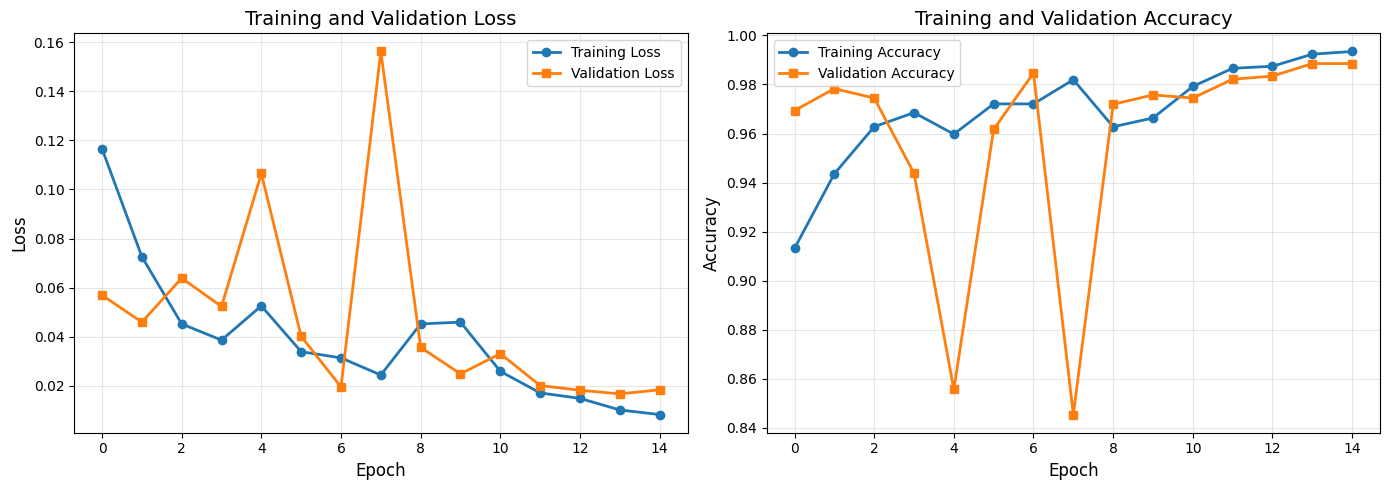

In [ ]:
# Cell 11: Ploting and saving training curves dissertation

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Loss curves
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', marker='o', linewidth=2)
plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Saving plots to Google Drive
plt.savefig(os.path.join(results_path, 'vgg16_training_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig('vgg16_training_curves.png', dpi=300, bbox_inches='tight')
print(f"Training curves saved to: {results_path}vgg16_training_curves.png")
plt.show()

Confusion matrix saved to: /content/drive/My Drive/pneumonia_detection/results/vgg16_confusion_matrix.png


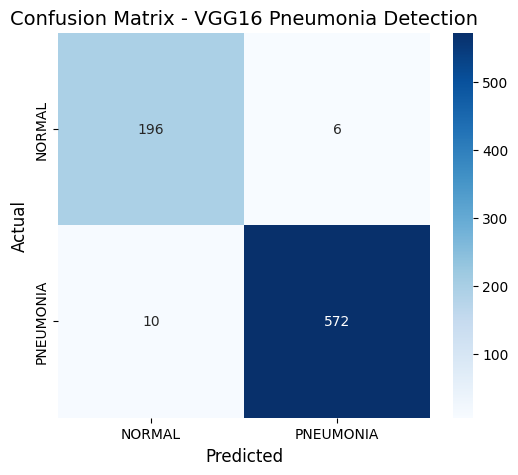

In [ ]:
# Cell 12: Plotting confusion matrix for dissertation

import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - VGG16 Pneumonia Detection', fontsize=14)

# Saving confusion matrix
plt.savefig(os.path.join(results_path, 'vgg16_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig('vgg16_confusion_matrix.png', dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {results_path}vgg16_confusion_matrix.png")
plt.show()

In [ ]:
# Cell 13: Downloading all results to my local computer
from google.colab import files

# List files downloaded
files_to_download = [
    'vgg16_best_model.pth',
    'vgg16_training_curves.png',
    'vgg16_confusion_matrix.png'
]

for file_name in files_to_download:
    try:
        files.download(file_name)
        print(f"Downloaded: {file_name}")
    except:
        print(f"Could not download: {file_name}")

print("\nAlso check your Google Drive for:")
print("  - pneumonia_detection/models/vgg16_best_model.pth")
print("  - pneumonia_detection/results/vgg16_test_results.txt")
print("  - pneumonia_detection/results/vgg16_training_curves.png")
print("  - pneumonia_detection/results/vgg16_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: vgg16_best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: vgg16_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: vgg16_confusion_matrix.png

Also check your Google Drive for:
  - pneumonia_detection/models/vgg16_best_model.pth
  - pneumonia_detection/results/vgg16_test_results.txt
  - pneumonia_detection/results/vgg16_training_curves.png
  - pneumonia_detection/results/vgg16_confusion_matrix.png
